## Installing and Importing Packages
*note: go do **SignLink\sign_lang_classification\venv1\Scripts\activate** first*

In [105]:
!pip install pandas numpy seaborn matplotlib scikit-learn glob2 xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 6.7 MB/s eta 0:00:15
   - -------------------------------------- 2.9/101.7 MB 6.6 MB/s eta 0:00:16
   - -------------------------------------- 4.7/101.7 MB 7.3 MB/s eta 0:00:14
   -- ------------------------------------- 6.6/101.7 MB 7.5 MB/s eta 0:00:13
   --- ------------------------------------ 8.1/101.7 MB 7.6 MB/s eta 0:00:13
   --- ------------------------------------ 9.7/101.7 MB 7.6 MB/s eta 0:00:13
   ---- ----------------------------------- 11.3/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 12.6/101.7 MB 7.5 MB/s eta 0:00:12
   ----- ---------------------------------- 14.2/101.7 MB 7.3 MB/s eta 0:00:13
   ------ --------------------------------- 15.7/101.7 MB 7.3 MB/s eta 0:00:12
   ------ --------------------------------- 17.0/101.7 MB 7.3 MB/s eta 0:0

In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,log_loss

import os
import csv

## Dataset Retrieval and Prep of Processed Data

In [14]:
print("Python is looking inside:", os.getcwd())
print("Does the dataset folder exist there?", os.path.exists(r"..\datasets\American_Sign_Language_Fingerspelling_dataset"))

Python is looking inside: c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification
Does the dataset folder exist there? True


In [15]:
dpath = r"..\datasets\American_Sign_Language_Fingerspelling_dataset"
pdpath = r"..\datasets\American_Sign_Language_Fingerspelling_dataset\processed_data\processed_sign_language_data.csv"

sign_data=[]  #list to compile all data 

# find every csv inside all user folders and put it into list 
for root, dirs, files in os.walk(dpath):
    folder=os.path.basename(root)
    if "User" in folder:
        for file in files:
            if file.endswith(".csv"):
                fpath= os.path.join(root, file)
                parts=file.split("_")
                letter=parts[2].upper()
                
                column_names = [
                    "emg1",
                    "emg2",
                    "emg3",
                    "emg4",
                    "emg5",
                    "emg6",
                    "emg7",
                    "emg8",

                    "accel_x",
                    "accel_y",
                    "accel_z",

                    "gyro_x",
                    "gyro_y",
                    "gyro_z",

                    "roll",
                    "pitch",
                    "yaw"
                ]

                df = pd.read_csv(fpath, header=None, names=column_names)
                df["label"] = letter
                sign_data.append(df)

print("Creation of processed data complete.")

# list -> dataframe -> saved csv of processed data
sign_df = pd.concat(sign_data, ignore_index=True)
sign_df.to_csv(pdpath, index=False)
print("Processed data saved as csv.")


Creation of processed data complete.
Processed data saved as csv.


In [16]:
# Load the processed data
pdata = pd.read_csv(pdpath)
print("Data loaded successfully. Here are the first five rows:")
display(pdata.head())
print()
print("Here are some insights about the data:")
print(pdata.info())
print()
print(pdata.describe())

Data loaded successfully. Here are the first five rows:


,emg1,emg2,emg3,emg4,emg5,emg6,emg7,emg8,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,roll,pitch,yaw,label
0,0,0,0,0,0,0,0,0,0.889160,-0.366211,0.250000,-2.8750,4.8125,-5.5000,63,27,33,A
1,0,0,0,0,0,0,0,0,0.925781,-0.345703,0.256836,-0.6875,-0.7500,2.2500,63,26,33,A
2,1,-1,-2,1,-4,-8,-22,-5,0.870117,-0.351562,0.219727,-9.1250,15.6875,-10.0625,63,26,33,A
3,15,0,-15,-3,-1,-3,-7,-27,0.951660,-0.318359,0.234863,-8.0000,3.6250,3.9375,63,27,32,A
4,-9,-18,-1,-9,-9,-1,75,20,0.927734,-0.322266,0.221680,-13.1875,21.3750,-3.4375,63,27,32,A



Here are some insights about the data:
<class 'pandas.DataFrame'>
RangeIndex: 61098 entries, 0 to 61097
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   emg1     61098 non-null  int64  
 1   emg2     61098 non-null  int64  
 2   emg3     61098 non-null  int64  
 3   emg4     61098 non-null  int64  
 4   emg5     61098 non-null  int64  
 5   emg6     61098 non-null  int64  
 6   emg7     61098 non-null  int64  
 7   emg8     61098 non-null  int64  
 8   accel_x  61098 non-null  float64
 9   accel_y  61098 non-null  float64
 10  accel_z  61098 non-null  float64
 11  gyro_x   61098 non-null  float64
 12  gyro_y   61098 non-null  float64
 13  gyro_z   61098 non-null  float64
 14  roll     61098 non-null  int64  
 15  pitch    61098 non-null  int64  
 16  yaw      61098 non-null  int64  
 17  label    61098 non-null  str    
dtypes: float64(6), int64(11), str(1)
memory usage: 8.4 MB
None

               emg1          emg2    

In [17]:
print(pdata.shape) #first value= rows, second value= columns
print()

print(pdata["label"].value_counts())
print()

print(pdata["label"].unique())

(61098, 18)

label
H    2448
K    2448
Y    2448
E    2397
I    2397
Q    2397
X    2397
B    2346
G    2346
M    2346
N    2346
P    2346
R    2346
S    2346
U    2346
V    2346
W    2346
Z    2346
A    2295
C    2295
D    2295
F    2295
J    2295
L    2295
O    2295
T    2295
Name: count, dtype: int64

<StringArray>
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O',
 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Length: 26, dtype: str


## Data Cleaning

In [18]:
# missing/null values
missing_values = pdata.isnull().sum()
print("Missing values in each column:", missing_values)

Missing values in each column: emg1       0
emg2       0
emg3       0
emg4       0
emg5       0
emg6       0
emg7       0
emg8       0
accel_x    0
accel_y    0
accel_z    0
gyro_x     0
gyro_y     0
gyro_z     0
roll       0
pitch      0
yaw        0
label      0
dtype: int64


In [19]:
# duplicated rows
duplicates = pdata.duplicated()
print(f"Number of duplicated rows: {duplicates.sum()}")


Number of duplicated rows: 1135


In [20]:
# View duplicated rows (put in csv file)
duplicate_mask = pdata.duplicated(keep=False)
duplicates_pdata = pdata[duplicate_mask]
ordered_duplicates = duplicates_pdata.sort_values(by=list(pdata.columns))
ordered_duplicates = ordered_duplicates.reset_index()

pdpath1 = r"..\datasets\American_Sign_Language_Fingerspelling_dataset\processed_data\duplicated_values.csv"
ordered_duplicates.to_csv(pdpath1, index=False)

In [21]:
# Remove duplicated from pdpath
pdpath = r"..\datasets\American_Sign_Language_Fingerspelling_dataset\processed_data\processed_sign_language_data.csv"
pdata = pd.read_csv(pdpath)
pdata = pdata.drop_duplicates()

pdpath2 = r"..\datasets\American_Sign_Language_Fingerspelling_dataset\processed_data\final_processed_values.csv"
pdata.to_csv(pdpath2, index=False)

# Check duplicated rows again
pdata1=pd.read_csv(pdpath2)
duplicates = pdata1.duplicated()
print(f"Number of duplicated rows: {duplicates.sum()}") 

Number of duplicated rows: 0


In [59]:
# count of each label 
final_data = pd.read_csv(pdpath2)
label_counts = final_data["label"].value_counts(normalize=True)*100
print("Count of each label:\n", label_counts)

Count of each label:
 label
Y    4.082518
H    3.997465
I    3.997465
K    3.997465
G    3.912413
M    3.912413
P    3.912413
R    3.912413
U    3.912413
V    3.912413
W    3.912413
Z    3.912413
A    3.827360
E    3.827360
J    3.827360
O    3.827360
S    3.827360
X    3.827360
C    3.825693
T    3.802345
N    3.770659
F    3.732302
D    3.677268
B    3.670597
L    3.657255
Q    3.525507
Name: proportion, dtype: float64


count    59963.000000
mean        -0.734253
std         13.652151
min       -128.000000
25%         -5.000000
50%         -1.000000
75%          4.000000
max        127.000000
Name: emg1, dtype: float64

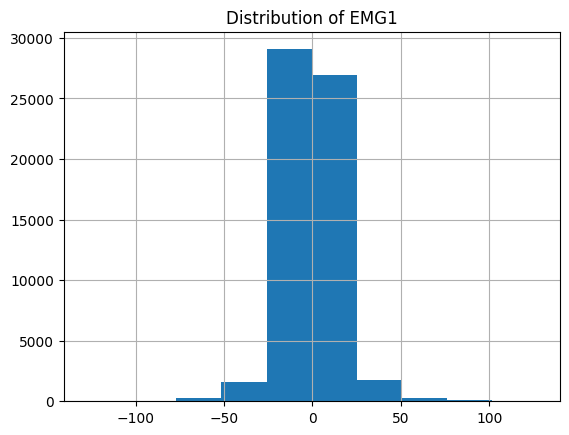

In [60]:
# Managing outliers in EMG1 using IQR method (histogram)
final_data["emg1"].hist()
plt.title("Distribution of EMG1")
final_data["emg1"].describe()

count    59963.000000
mean        -0.906559
std         16.406903
min       -128.000000
25%         -6.000000
50%         -1.000000
75%          4.000000
max        127.000000
Name: emg2, dtype: float64

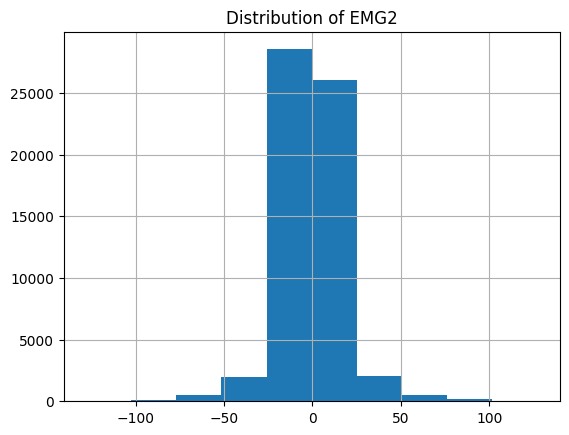

In [61]:
# Managing outliers in EMG2 using IQR method (histogram)
final_data["emg2"].hist()
plt.title("Distribution of EMG2")
final_data["emg2"].describe()

count    59963.000000
mean        -0.927005
std         19.719064
min       -128.000000
25%         -7.000000
50%         -1.000000
75%          5.000000
max        127.000000
Name: emg3, dtype: float64

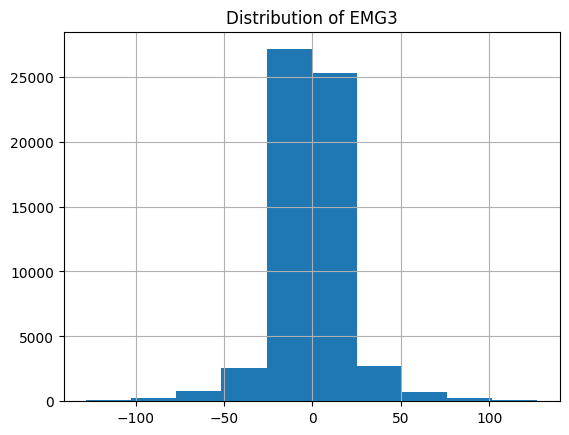

In [62]:
# Managing outliers in EMG3 using IQR method (histogram)
final_data["emg3"].hist()
plt.title("Distribution of EMG3")
final_data["emg3"].describe()

count    59963.000000
mean        -0.745710
std          9.590749
min       -113.000000
25%         -4.000000
50%         -1.000000
75%          3.000000
max        114.000000
Name: emg4, dtype: float64

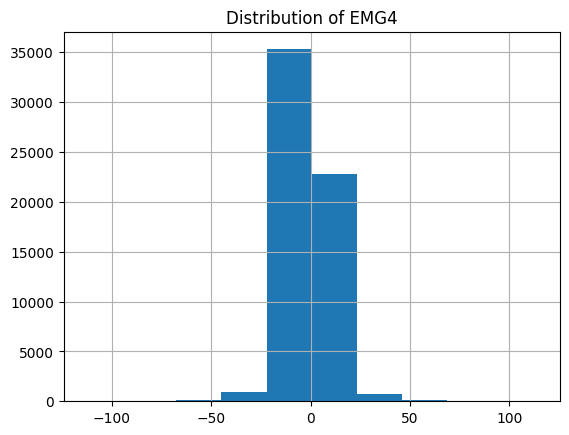

In [63]:
# Managing outliers in EMG4 using IQR method (histogram)
final_data["emg4"].hist()
plt.title("Distribution of EMG4")
final_data["emg4"].describe()

count    59963.000000
mean        -0.788420
std          9.371364
min        -96.000000
25%         -5.000000
50%         -1.000000
75%          3.000000
max        122.000000
Name: emg5, dtype: float64

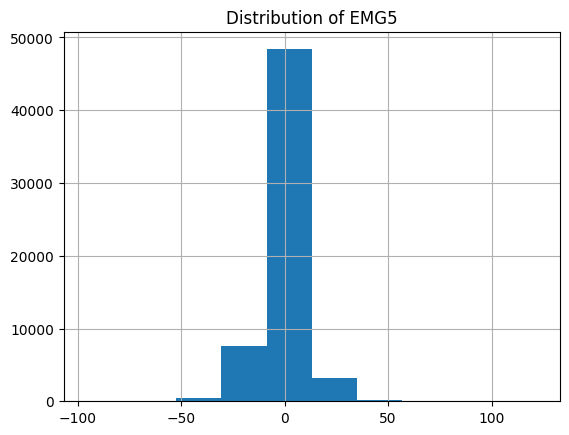

In [64]:
# Managing outliers in EMG5 using IQR method (histogram)
final_data["emg5"].hist()
plt.title("Distribution of EMG5")
final_data["emg5"].describe()

count    59963.000000
mean        -0.858146
std         19.403576
min       -128.000000
25%         -8.000000
50%         -1.000000
75%          6.000000
max        127.000000
Name: emg6, dtype: float64

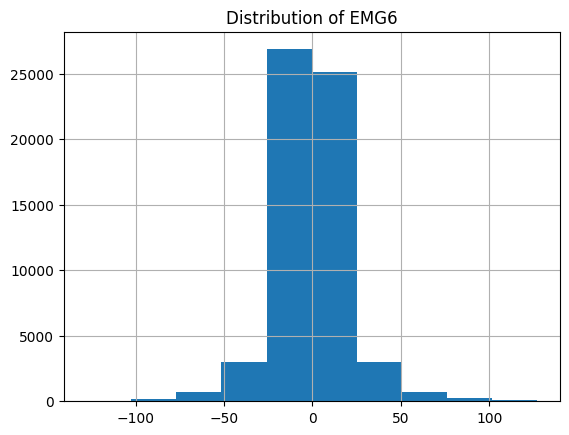

In [65]:
# Managing outliers in EMG6 using IQR method (histogram)
final_data["emg6"].hist()
plt.title("Distribution of EMG6")
final_data["emg6"].describe()

count    59963.000000
mean        -0.840785
std         21.238845
min       -128.000000
25%         -8.000000
50%         -1.000000
75%          6.000000
max        127.000000
Name: emg7, dtype: float64

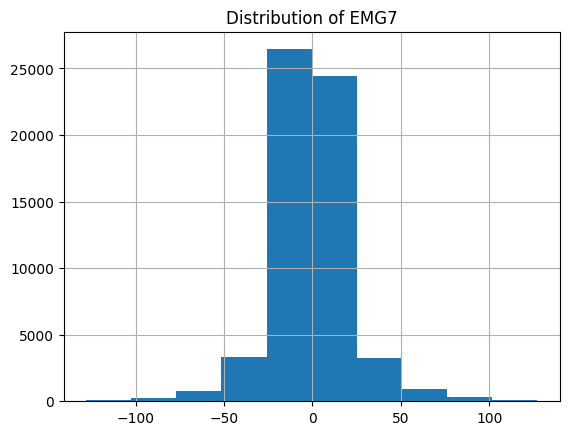

In [66]:
# Managing outliers in EMG7 using IQR method (histogram)
final_data["emg7"].hist()
plt.title("Distribution of EMG7")
final_data["emg7"].describe()

count    59963.000000
mean        -0.959692
std         18.126399
min       -128.000000
25%         -7.000000
50%         -1.000000
75%          5.000000
max        127.000000
Name: emg8, dtype: float64

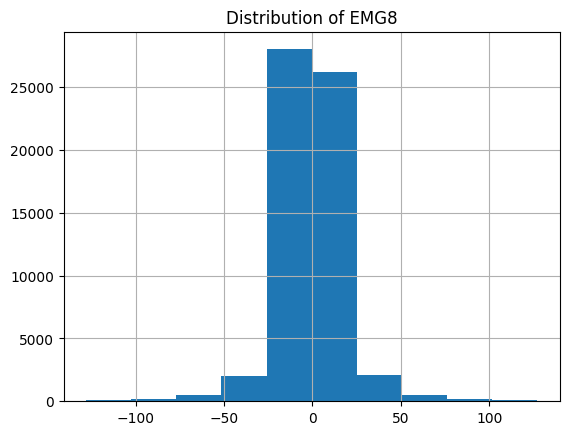

In [67]:
# Managing outliers in EMG8 using IQR method (histogram)
final_data["emg8"].hist()
plt.title("Distribution of EMG8")
final_data["emg8"].describe()

count    59963.000000
mean         0.550465
std          0.491401
min         -1.073730
25%          0.592285
50%          0.723633
75%          0.813965
max          1.374020
Name: accel_x, dtype: float64

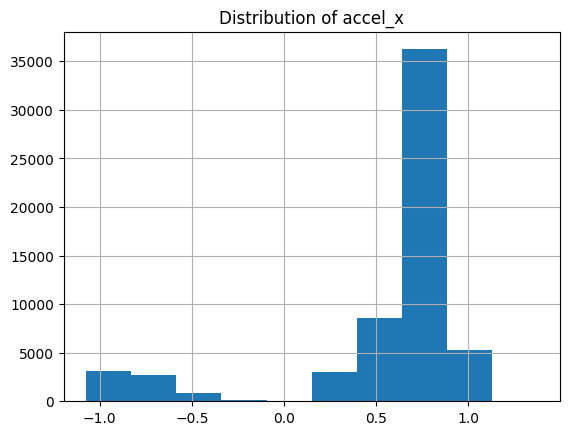

In [68]:
# Managing outliers in accel_x using IQR method (histogram)
final_data["accel_x"].hist()
plt.title("Distribution of accel_x")
final_data["accel_x"].describe()

count    59963.000000
mean        -0.350381
std          0.332978
min         -1.004390
25%         -0.548828
50%         -0.411133
75%         -0.312012
max          1.083980
Name: accel_y, dtype: float64

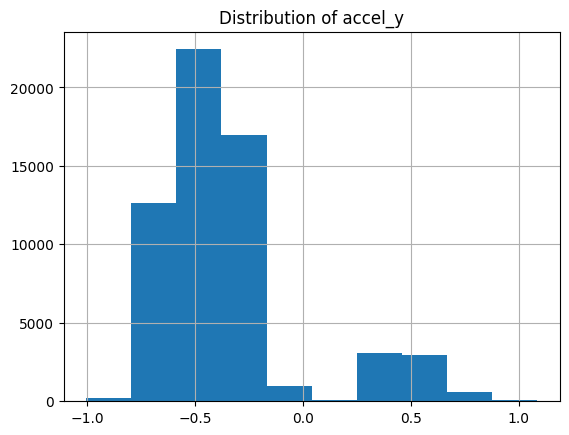

In [69]:
# Managing outliers in accel_y using IQR method (histogram)
final_data["accel_y"].hist()
plt.title("Distribution of accel_y")
final_data["accel_y"].describe()

count    59963.000000
mean         0.466688
std          0.135627
min         -0.436523
25%          0.375977
50%          0.477051
75%          0.566895
max          1.086910
Name: accel_z, dtype: float64

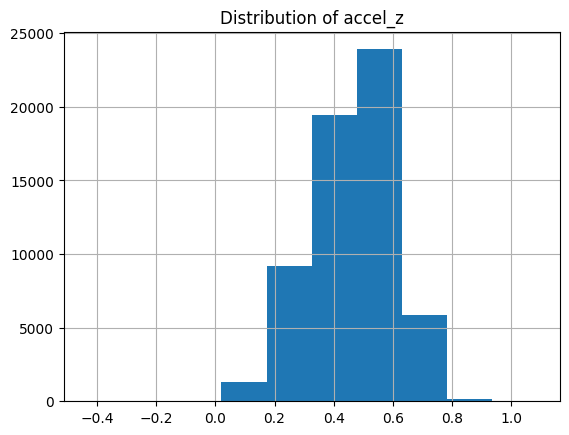

In [70]:
# Managing outliers in accel_z using IQR method (histogram)
final_data["accel_z"].hist()
plt.title("Distribution of accel_z")
final_data["accel_z"].describe()

count    59963.000000
mean         0.318656
std          6.235241
min        -89.000000
25%         -0.812500
50%          0.062500
75%          1.062500
max        137.188000
Name: gyro_x, dtype: float64

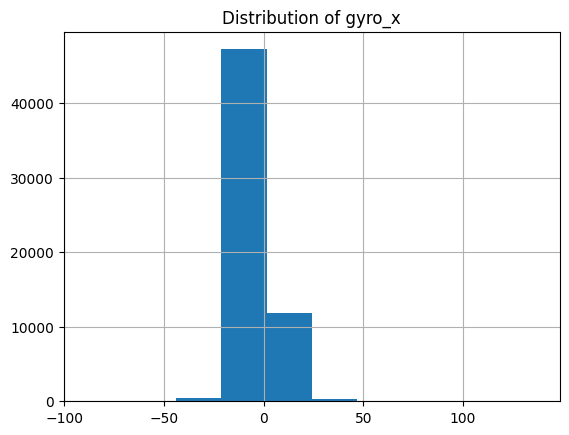

In [71]:
# Managing outliers in gyro_x using IQR method (histogram)
final_data["gyro_x"].hist()
plt.title("Distribution of gyro_x")
final_data["gyro_x"].describe()

count    59963.000000
mean        -0.673218
std          9.040854
min       -101.938000
25%         -1.812500
50%         -0.250000
75%          0.562500
max        120.312000
Name: gyro_y, dtype: float64

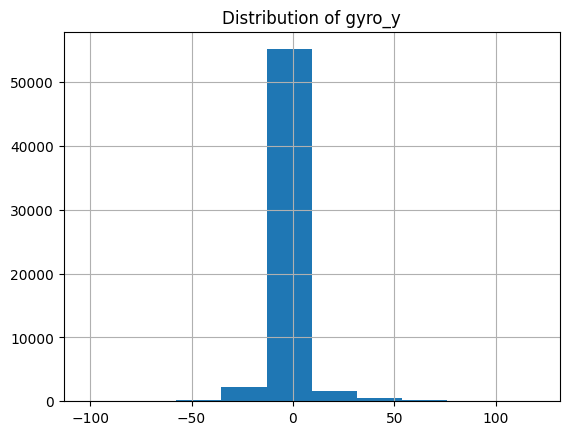

In [72]:
# Managing outliers in gyro_y using IQR method (histogram)
final_data["gyro_y"].hist()
plt.title("Distribution of gyro_y")
final_data["gyro_y"].describe()

count    59963.000000
mean        -1.438337
std         10.434716
min       -171.938000
25%         -1.312500
50%         -0.125000
75%          0.812500
max        114.875000
Name: gyro_z, dtype: float64

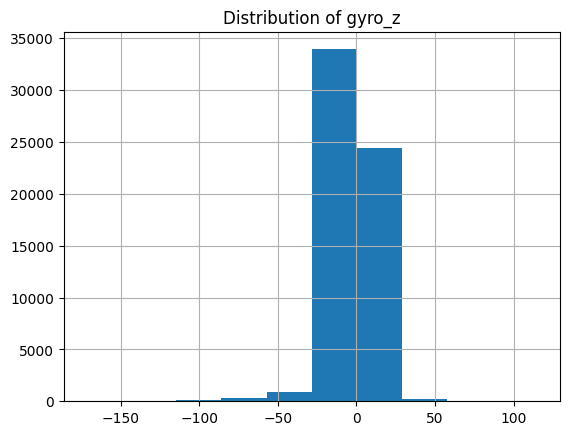

In [73]:
# Managing outliers in gyro_z using IQR method (histogram)
final_data["gyro_z"].hist()
plt.title("Distribution of gyro_z")
final_data["gyro_z"].describe()

count    59963.000000
mean        72.598386
std         15.615104
min         47.000000
25%         64.000000
50%         68.000000
75%         73.000000
max        126.000000
Name: roll, dtype: float64

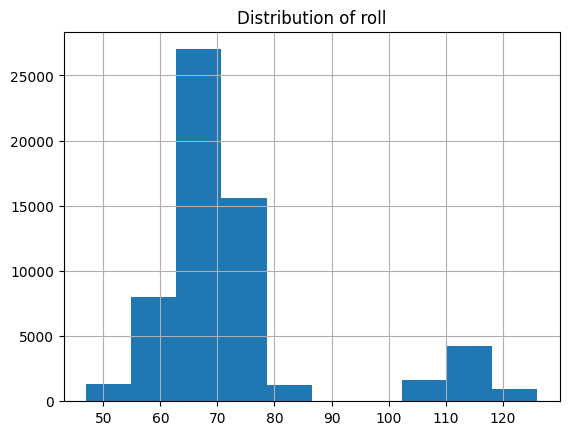

In [74]:
# Managing outliers in roll using IQR method (histogram)
final_data["roll"].hist()
plt.title("Distribution of roll")
final_data["roll"].describe()

count    59963.000000
mean        53.047146
std         33.032016
min         11.000000
25%         35.000000
50%         43.000000
75%         53.000000
max        162.000000
Name: pitch, dtype: float64

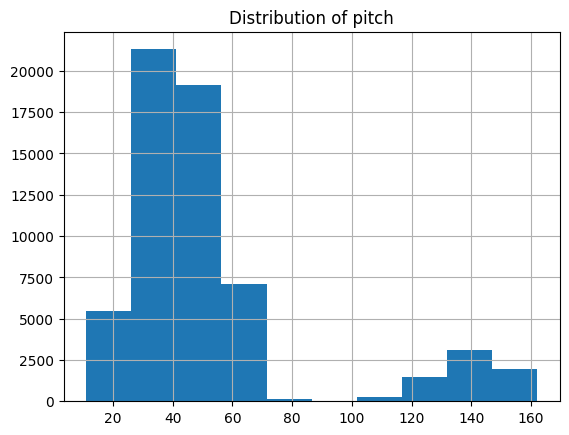

In [75]:
# Managing outliers in pitch using IQR method (histogram)
final_data["pitch"].hist()
plt.title("Distribution of pitch")
final_data["pitch"].describe()

count    59963.000000
mean       102.901339
std         45.817718
min          0.000000
25%         63.000000
50%        107.000000
75%        144.000000
max        179.000000
Name: yaw, dtype: float64

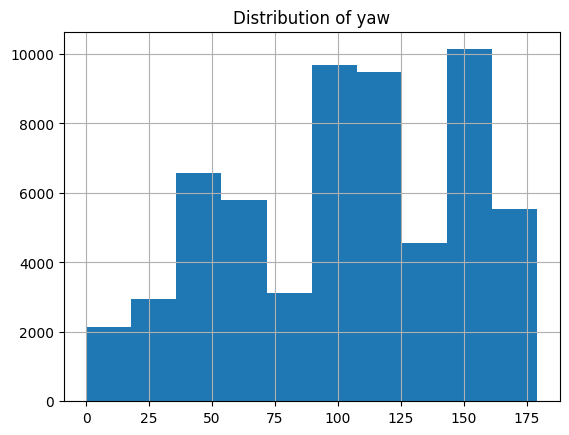

In [76]:
# Managing outliers in yaw using IQR method (histogram)
final_data["yaw"].hist()
plt.title("Distribution of yaw")
final_data["yaw"].describe()

## Label Encoding

In [78]:
# X removes the label (alphabet) column and keeps all the other columns as features
X = final_data.drop(
    "label",
    axis=1
)

# Y keeps only the label (alphabet) column as the target variable
y = final_data["label"]


In [79]:
#Check duplication for x
duplicates_x = X.duplicated()
print(f"Number of duplicated rows in X: {duplicates_x.sum()}")

Number of duplicated rows in X: 0


In [80]:
#Checking
print("X:")
print(X.head())
print()

print("Y:")
print(y.head())

X:
   emg1  emg2  emg3  emg4  emg5  emg6  emg7  emg8   accel_x   accel_y  \
0     0     0     0     0     0     0     0     0  0.889160 -0.366211   
1     0     0     0     0     0     0     0     0  0.925781 -0.345703   
2     1    -1    -2     1    -4    -8   -22    -5  0.870117 -0.351562   
3    15     0   -15    -3    -1    -3    -7   -27  0.951660 -0.318359   
4    -9   -18    -1    -9    -9    -1    75    20  0.927734 -0.322266   

    accel_z   gyro_x   gyro_y   gyro_z  roll  pitch  yaw  
0  0.250000  -2.8750   4.8125  -5.5000    63     27   33  
1  0.256836  -0.6875  -0.7500   2.2500    63     26   33  
2  0.219727  -9.1250  15.6875 -10.0625    63     26   33  
3  0.234863  -8.0000   3.6250   3.9375    63     27   32  
4  0.221680 -13.1875  21.3750  -3.4375    63     27   32  

Y:
0    A
1    A
2    A
3    A
4    A
Name: label, dtype: str


In [81]:
# label encoding a b c to 0 1 2 correspondingly
le = LabelEncoder()                   
pdata_encoded = le.fit_transform(y)
print("Labels encoded successfully. Here are the unique encoded labels:")
print(np.unique(pdata_encoded))
print(np.unique(y))
    

Labels encoded successfully. Here are the unique encoded labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


## Training

In [88]:
# 80% training & 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    pdata_encoded,
    test_size=0.2,
    random_state=42,
    stratify=pdata_encoded
)

### Decision Tree

In [98]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [99]:
y_preddt = dt_classifier.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_preddt))
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_preddt)
))

Baseline Accuracy: 0.8866838989410489
              precision    recall  f1-score   support

           A       0.93      0.91      0.92       459
           B       0.92      0.90      0.91       440
           C       0.90      0.90      0.90       459
           D       0.88      0.92      0.90       441
           E       0.91      0.92      0.92       459
           F       0.90      0.88      0.89       448
           G       0.89      0.91      0.90       469
           H       0.88      0.90      0.89       480
           I       0.90      0.91      0.91       480
           J       0.81      0.76      0.79       459
           K       0.91      0.92      0.92       479
           L       0.88      0.86      0.87       439
           M       0.83      0.84      0.83       469
           N       0.82      0.84      0.83       452
           O       0.86      0.88      0.87       459
           P       0.88      0.84      0.86       469
           Q       0.93      0.94      0.93

Accuracy: 0.8866838989410489


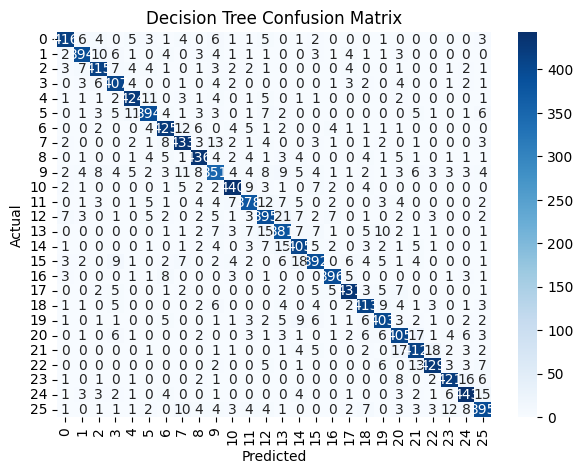

In [101]:
accuracy = accuracy_score(y_test, y_preddt)
print("Accuracy:", accuracy)
confusion = confusion_matrix(y_test, y_preddt)

#figure
plt.figure(figsize=(7, 5))
sns.heatmap(confusion, annot=True, cmap="Blues", fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest

In [102]:
rf_classifier = RandomForestClassifier( 
    random_state=42,
    n_estimators=300,
    criterion="gini",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1
    )
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [103]:
y_predrf = rf_classifier.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_predrf))
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_predrf)
))

Random Forest Accuracy: 0.9197865421495872
              precision    recall  f1-score   support

           A       0.94      0.92      0.93       459
           B       0.97      0.91      0.94       440
           C       0.95      0.95      0.95       459
           D       0.95      0.95      0.95       441
           E       0.92      0.91      0.91       459
           F       0.90      0.93      0.92       448
           G       0.93      0.96      0.95       469
           H       0.93      0.93      0.93       480
           I       0.90      0.96      0.93       480
           J       0.85      0.84      0.84       459
           K       0.93      0.93      0.93       479
           L       0.89      0.90      0.89       439
           M       0.87      0.89      0.88       469
           N       0.85      0.89      0.87       452
           O       0.90      0.90      0.90       459
           P       0.92      0.91      0.91       469
           Q       0.96      0.97     

Accuracy: 0.9197865421495872


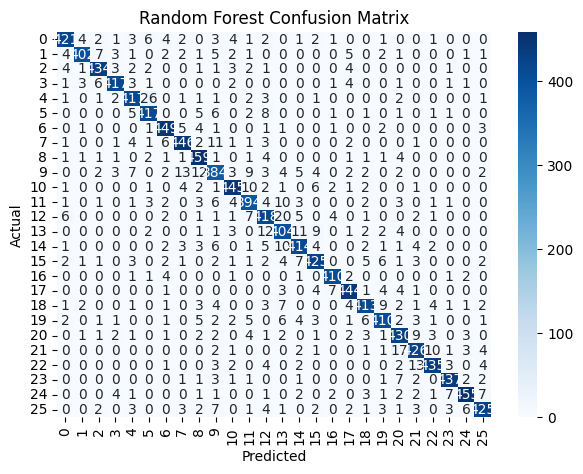

In [104]:
accuracy = accuracy_score(y_test, y_predrf)
print("Accuracy:", accuracy)
confusion = confusion_matrix(y_test, y_predrf)

#figure
plt.figure(figsize=(7, 5))
sns.heatmap(confusion, annot=True, cmap="Blues", fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### XGBoost

In [111]:
xgb_baseline = XGBClassifier(
    objective="multi:softprob",
    numclass=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xgb_baseline.fit(X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True)

baseline_results = xgb_baseline.evals_result()

[0]	validation_0-mlogloss:3.07388	validation_1-mlogloss:3.07657


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:29:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[1]	validation_0-mlogloss:2.92008	validation_1-mlogloss:2.92587
[2]	validation_0-mlogloss:2.79504	validation_1-mlogloss:2.80178
[3]	validation_0-mlogloss:2.68522	validation_1-mlogloss:2.69517
[4]	validation_0-mlogloss:2.58469	validation_1-mlogloss:2.59740
[5]	validation_0-mlogloss:2.49976	validation_1-mlogloss:2.51435
[6]	validation_0-mlogloss:2.41450	validation_1-mlogloss:2.43076
[7]	validation_0-mlogloss:2.33729	validation_1-mlogloss:2.35610
[8]	validation_0-mlogloss:2.26969	validation_1-mlogloss:2.29110
[9]	validation_0-mlogloss:2.19571	validation_1-mlogloss:2.22066
[10]	validation_0-mlogloss:2.14061	validation_1-mlogloss:2.16688
[11]	validation_0-mlogloss:2.07660	validation_1-mlogloss:2.10448
[12]	validation_0-mlogloss:2.01899	validation_1-mlogloss:2.04779
[13]	validation_0-mlogloss:1.96302	validation_1-mlogloss:1.99418
[14]	validation_0-mlogloss:1.91214	validation_1-mlogloss:1.94492
[15]	validation_0-mlogloss:1.86529	validation_1-mlogloss:1.90022
[16]	validation_0-mlogloss:1.81975

In [112]:
y_predxg = xgb_baseline.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_predxg))
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_predxg)
))

XGBoost Accuracy: 0.9201200700408572
              precision    recall  f1-score   support

           A       0.93      0.90      0.92       459
           B       0.96      0.92      0.94       440
           C       0.94      0.96      0.95       459
           D       0.94      0.92      0.93       441
           E       0.95      0.93      0.94       459
           F       0.94      0.93      0.93       448
           G       0.93      0.95      0.94       469
           H       0.94      0.93      0.93       480
           I       0.90      0.94      0.92       480
           J       0.89      0.85      0.87       459
           K       0.92      0.94      0.93       479
           L       0.88      0.91      0.90       439
           M       0.85      0.87      0.86       469
           N       0.84      0.87      0.85       452
           O       0.90      0.90      0.90       459
           P       0.93      0.91      0.92       469
           Q       0.96      0.97      0.96 

Accuracy: 0.9201200700408572


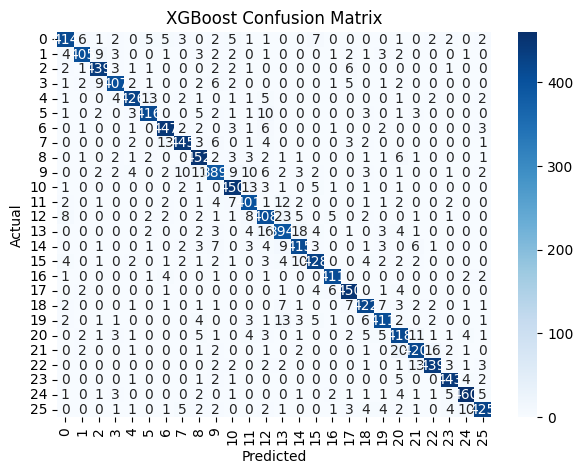

In [113]:
accuracy = accuracy_score(y_test, y_predxg)
print("Accuracy:", accuracy)
confusion = confusion_matrix(y_test, y_predxg)

#figure
plt.figure(figsize=(7, 5))
sns.heatmap(confusion, annot=True, cmap="Blues", fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Hyperparameter Tuning (do not re-run: takes long time)

In [115]:
#### Hyperparameter Tuning for XGBoost using RandomizedSearchCV
param_dist = {
    "n_estimators": [200, 300, 400,500,600],
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.03, 0.05, 0.07,0.09,1],
    "subsample": [0.7, 0.8, 0.9,1.0],
    "colsample_bytree": [0.7, 0.8, 0.9,1.0],
    "min_child_weight": [1, 4, 7,10],
}

xgb_base = XGBClassifier(
    objective="multi:softprob",
    numclass=len(le.classes_),
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=1,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,#it was 20 before
    scoring="accuracy",
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=42
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:05:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.09, max_depth=4, min_child_weight=10, n_estimators=400, subsample=0.9; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:06:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.09, max_depth=4, min_child_weight=10, n_estimators=400, subsample=0.9; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:07:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.09, max_depth=4, min_child_weight=10, n_estimators=400, subsample=0.9; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:09:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=4, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  37.1s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:09:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=4, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  36.0s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:10:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=4, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  36.7s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:11:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=4, min_child_weight=10, n_estimators=200, subsample=0.7; total time=  40.2s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:11:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=4, min_child_weight=10, n_estimators=200, subsample=0.7; total time=  39.9s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:12:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=4, min_child_weight=10, n_estimators=200, subsample=0.7; total time=  40.2s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:13:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=6, min_child_weight=4, n_estimators=400, subsample=0.9; total time= 1.6min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:14:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=6, min_child_weight=4, n_estimators=400, subsample=0.9; total time= 1.6min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=6, min_child_weight=4, n_estimators=400, subsample=0.9; total time=   0.0s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time=  59.0s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:39:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time=  58.9s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:40:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time=  58.9s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:41:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=8, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:43:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=8, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:44:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=8, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:45:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=1, max_depth=6, min_child_weight=1, n_estimators=500, subsample=0.7; total time= 2.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:47:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=1, max_depth=6, min_child_weight=1, n_estimators=500, subsample=0.7; total time= 2.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:50:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=1, max_depth=6, min_child_weight=1, n_estimators=500, subsample=0.7; total time= 1.8min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:52:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=7, min_child_weight=7, n_estimators=500, subsample=0.7; total time= 2.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:54:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=7, min_child_weight=7, n_estimators=500, subsample=0.7; total time= 2.2min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:56:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=7, min_child_weight=7, n_estimators=500, subsample=0.7; total time= 2.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:58:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=1, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 2.0min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:00:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=1, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 2.0min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:02:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=1, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 2.0min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:04:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=7, min_child_weight=4, n_estimators=300, subsample=0.8; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:05:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=7, min_child_weight=4, n_estimators=300, subsample=0.8; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:07:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=7, min_child_weight=4, n_estimators=300, subsample=0.8; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:08:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=10, n_estimators=300, subsample=0.9; total time=  57.4s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:09:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=10, n_estimators=300, subsample=0.9; total time=  53.6s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:10:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=10, n_estimators=300, subsample=0.9; total time= 1.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:11:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 1.2min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:12:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 1.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:13:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=5, min_child_weight=7, n_estimators=500, subsample=0.9; total time= 2.0min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:15:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time= 1.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:17:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time= 1.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:18:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=300, subsample=0.9; total time= 1.1min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:19:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=8, min_child_weight=7, n_estimators=600, subsample=0.9; total time= 2.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=8, min_child_weight=7, n_estimators=600, subsample=0.9; total time= 2.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:24:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.09, max_depth=8, min_child_weight=7, n_estimators=600, subsample=0.9; total time= 2.7min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:27:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:29:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:30:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.09, max_depth=7, min_child_weight=1, n_estimators=300, subsample=0.7; total time= 1.6min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:32:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.09, max_depth=7, min_child_weight=1, n_estimators=300, subsample=0.7; total time= 1.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.09, max_depth=7, min_child_weight=1, n_estimators=300, subsample=0.7; total time= 1.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:35:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=8, min_child_weight=7, n_estimators=400, subsample=1.0; total time= 1.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:37:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=8, min_child_weight=7, n_estimators=400, subsample=1.0; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=8, min_child_weight=7, n_estimators=400, subsample=1.0; total time=   0.0s


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:23:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=5, min_child_weight=4, n_estimators=600, subsample=1.0; total time= 1.6min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:25:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=5, min_child_weight=4, n_estimators=600, subsample=1.0; total time= 1.7min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:26:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.07, max_depth=5, min_child_weight=4, n_estimators=600, subsample=1.0; total time= 1.7min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.3min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:29:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.0min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=1, max_depth=6, min_child_weight=10, n_estimators=400, subsample=1.0; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:32:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=400, subsample=0.9; total time= 1.5min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:33:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=400, subsample=0.9; total time= 1.4min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:35:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=400, subsample=0.9; total time= 1.7min


c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:36:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 5, ...], 'min_child_weight': [1, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [116]:
search.best_score_

np.float64(0.9236189284969774)

In [117]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results[["mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head()

,mean_test_score,std_test_score
15,0.923619,0.001872
13,0.921013,0.001033
16,0.919095,0.001823
3,0.918345,0.001394
5,0.916010,0.001382


## Training dataset

In [119]:
best_model = search.best_estimator_

best_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True)
y_pred_tuned = best_model.predict(X_test)

c:\Users\SombatlaTrucDeydeepy\Desktop\Github\SignLink\sign_lang_classification\venv1\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:56:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "numclass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:2.86472	validation_1-mlogloss:2.87425
[1]	validation_0-mlogloss:2.59865	validation_1-mlogloss:2.61606
[2]	validation_0-mlogloss:2.39629	validation_1-mlogloss:2.41907
[3]	validation_0-mlogloss:2.21859	validation_1-mlogloss:2.24831
[4]	validation_0-mlogloss:2.07700	validation_1-mlogloss:2.11412
[5]	validation_0-mlogloss:1.95941	validation_1-mlogloss:2.00028
[6]	validation_0-mlogloss:1.84252	validation_1-mlogloss:1.88710
[7]	validation_0-mlogloss:1.73587	validation_1-mlogloss:1.78546
[8]	validation_0-mlogloss:1.65526	validation_1-mlogloss:1.70911
[9]	validation_0-mlogloss:1.56521	validation_1-mlogloss:1.62242
[10]	validation_0-mlogloss:1.49609	validation_1-mlogloss:1.55610
[11]	validation_0-mlogloss:1.41943	validation_1-mlogloss:1.48192
[12]	validation_0-mlogloss:1.36089	validation_1-mlogloss:1.42567
[13]	validation_0-mlogloss:1.30167	validation_1-mlogloss:1.36866
[14]	validation_0-mlogloss:1.24834	validation_1-mlogloss:1.31765
[15]	validation_0-mlogloss:1.20039	

In [120]:
y_pred_tuned = best_model.predict(X_test)

print("Tuned Accuracy for XGBoost with all features:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred_tuned)
))

Tuned Accuracy for XGBoost with all features: 0.938797631951972
              precision    recall  f1-score   support

           A       0.96      0.94      0.95       459
           B       0.97      0.93      0.95       440
           C       0.95      0.97      0.96       459
           D       0.96      0.95      0.95       441
           E       0.96      0.94      0.95       459
           F       0.95      0.96      0.96       448
           G       0.95      0.96      0.96       469
           H       0.96      0.95      0.96       480
           I       0.93      0.95      0.94       480
           J       0.90      0.90      0.90       459
           K       0.96      0.95      0.95       479
           L       0.92      0.92      0.92       439
           M       0.87      0.92      0.89       469
           N       0.88      0.89      0.89       452
           O       0.92      0.92      0.92       459
           P       0.94      0.94      0.94       469
           Q     